# Installations

In [2]:
#!pip install paddlepaddle paddleocr pillow numpy opencv-python matplotlib pandas requests jiwer

### Imports

In [4]:
import os
import re
import platform
import urllib.request
import requests
import json
from importlib.metadata import version as package_version

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import paddle
from paddleocr import PaddleOCR

from PIL import Image
from jiwer import wer, cer

C:\ProgramData\anaconda3\envs\classicalOCR_env\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
C:\ProgramData\anaconda3\envs\classicalOCR_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


### Download models and Version Check

In [8]:
OCR_DEVICE = "gpu:0" if paddle.device.is_compiled_with_cuda() else "cpu"

OCR_MODEL_VERSION = "PP-OCRv5"
OCR_LANGUAGE = "en"

ocr = PaddleOCR(
    ocr_version=OCR_MODEL_VERSION,
    lang=OCR_LANGUAGE,
    device=OCR_DEVICE,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)


def _paddle_result_to_dict(result):


    payload = result.json

    if callable(payload):
        payload = payload()

    if isinstance(payload, str):
        payload = json.loads(payload)

    if not isinstance(payload, dict):
        raise TypeError(
            f"Unexpected PaddleOCR result type: {type(payload)!r}"
        )

    if isinstance(payload.get("res"), dict):
        payload = payload["res"]

    return payload


def _run_paddleocr(image_path):


    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    predictions = list(
        ocr.predict(
            image_path,
            text_rec_score_thresh=0.0,
        )
    )

    if not predictions:
        return {
            "rec_texts": [],
            "rec_scores": [],
            "rec_boxes": [],
            "rec_polys": [],
        }

    return _paddle_result_to_dict(predictions[0])


print(f"PP-OCRv5 initialized on: {OCR_DEVICE}")

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


PP-OCRv5 initialized on: cpu


In [13]:
print("--Software Versions--")

print(f"PaddlePaddle version: {paddle.__version__}")
print(f"PaddleOCR package version: {package_version('paddleocr')}")

print("\n--OCR Model--")

print(f"OCR model version: {OCR_MODEL_VERSION}")
print(f"OCR language configuration: {OCR_LANGUAGE}")
print(f"Device: {OCR_DEVICE}")


--Software Versions--
PaddlePaddle version: 3.2.2
PaddleOCR package version: 3.4.1

--OCR Model--
OCR model version: PP-OCRv5
OCR language configuration: en
Device: cpu


# Draw Bounding Box

In [15]:
def draw_bounding_boxes(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    data = _run_paddleocr(image_path)
    boxes = np.asarray(data.get("rec_boxes", []), dtype=int)

    for x_min, y_min, x_max, y_max in boxes:
        cv2.rectangle(
            image,
            (x_min, y_min),
            (x_max, y_max),
            (0, 255, 0),
            1
        )

    plt.figure(figsize=(8, 12))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Text Boxes (PP-OCRv5): {image_path}")
    plt.axis("off")
    plt.show()

### English Dataset Directory

In [16]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

### Test image

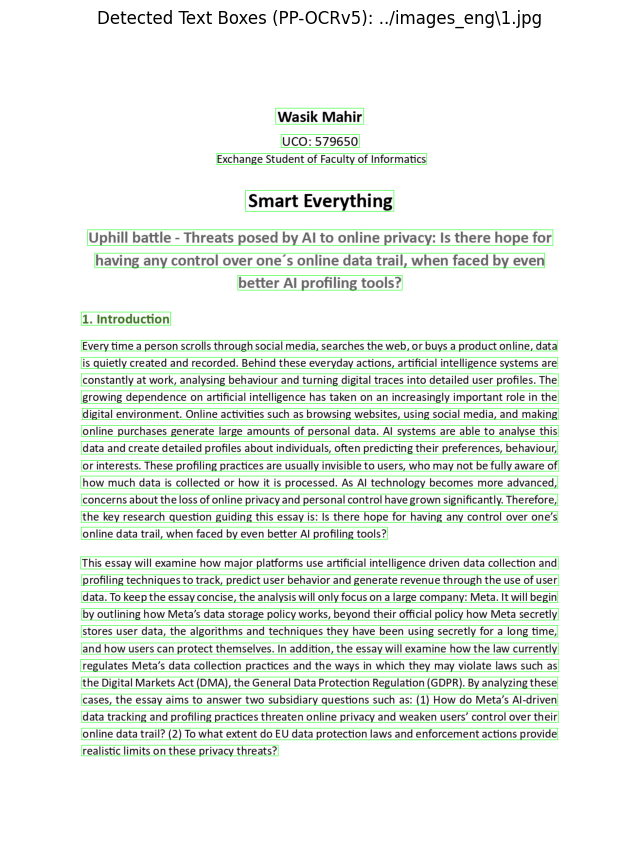

In [18]:
draw_bounding_boxes(os.path.join(ENG_IMAGES_DIR, "1.jpg"))

# Experiment 1 - Clean Baseline
Original image to OCR, Without preprocessing

In [21]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

In [22]:
def extract_text_paddleOCR(image_path):

    data = _run_paddleocr(image_path)

    text = "\n".join(
        str(text).strip()
        for text in data.get("rec_texts", [])
        if str(text).strip()
    )

    return text

In [23]:
# test image
text = extract_text_paddleOCR(os.path.join(ENG_IMAGES_DIR, "3.jpg"))

In [24]:
print(text)

In May 2o23, another incident happened again with Ireland's Data Protection Commission (DPC). The DPC
fined meta £1.2 billion for mishandling the personal data of European users, marking the largest penalty ever
under the EU's General Data Protection Regulation (GDPR) [5]. The fine came after a long investigation into
how the company transferred user data from the Eu to the United States of America without adequate
safeguards, despite a European Court of Justice ruling reguiring strong protections for such transfers [5]. The
DPC found +hat meta continued to send large volumes of Facebook users' personal data to the USA on the basis
of standard contractual clauses (Sccs) +hat did not sufficiently protect individuals' privacy rights, exposing
+hat data to potential access by US intelligence agencies. Because +hese clauses failed to meet GDPR standards,
the regulator concluded that meta was in breach of Article 46(1) of +he GDpR [18], which governs secure
international data transfers [5].

### Extract text from all images

In [25]:
pages = [1,2,3,4,5,6] 


Page 1


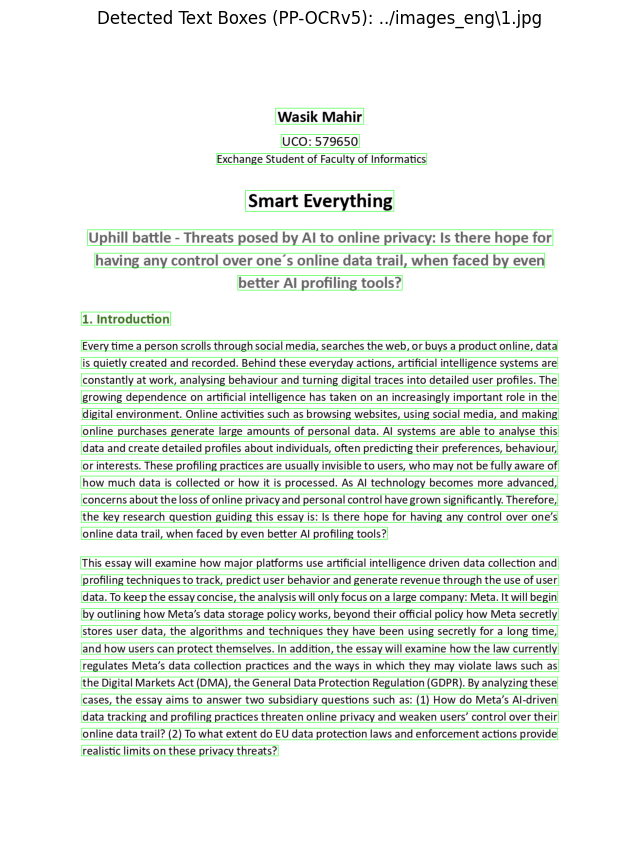

Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Smart Everything
Uphill battle - Threats posed by Al to online privacy: Is there hope for
having any control over one's online data trail, when faced by even
better Al profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling practices are u

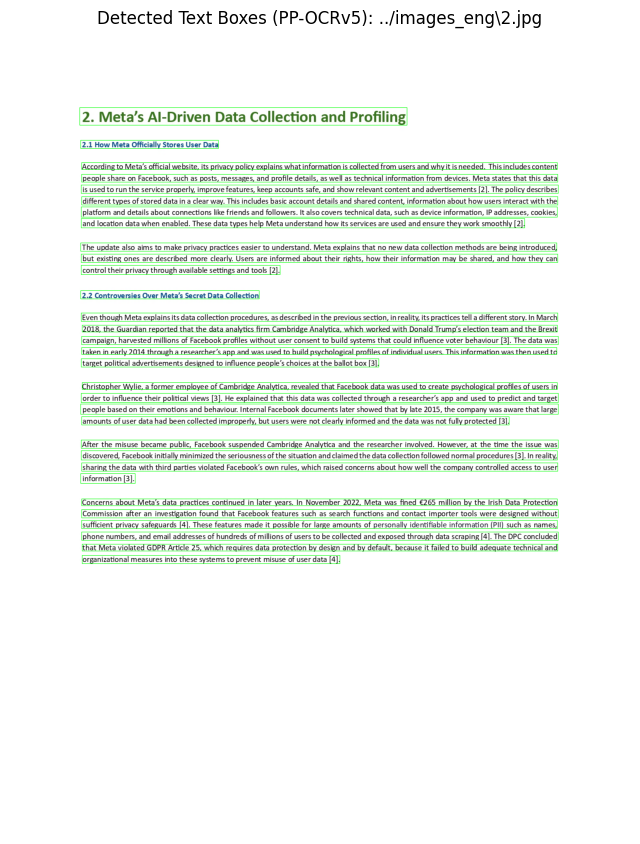

2. Meta's Al-Driven Data Collection and Profiling
2.1 How Meta Officially Stores User Data
According to Meta's official website, its privacy policy explains what information is collected from users and why it is needed. This includes content
people share on Facebook, such as posts, messages, and profile details, as well as technical information from devices. Meta states that this data
is used to run the service properly, improve features, keep accounts safe, and show relevant content and advertisements [2]. The policy describes
different types of stored data in a clear way. This includes basic account details and shared content, information about how users interact with the
platform and details about connections like friends and followers. It also covers technical data, such as device information, IP addresses, cookies,
and location data when enabled. These data types help Meta understand how its services are used and ensure they work smoothly [2].
The update also aims to make privacy 

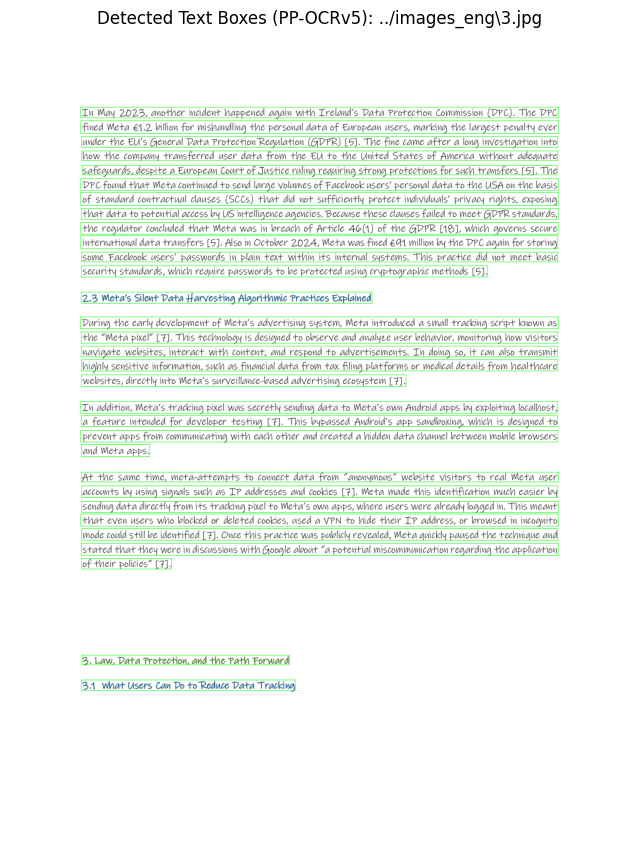

In May 2o23, another incident happened again with Ireland's Data Protection Commission (DPC). The DPC
fined meta £1.2 billion for mishandling the personal data of European users, marking the largest penalty ever
under the EU's General Data Protection Regulation (GDPR) [5]. The fine came after a long investigation into
how the company transferred user data from the Eu to the United States of America without adequate
safeguards, despite a European Court of Justice ruling reguiring strong protections for such transfers [5]. The
DPC found +hat meta continued to send large volumes of Facebook users' personal data to the USA on the basis
of standard contractual clauses (Sccs) +hat did not sufficiently protect individuals' privacy rights, exposing
+hat data to potential access by US intelligence agencies. Because +hese clauses failed to meet GDPR standards,
the regulator concluded that meta was in breach of Article 46(1) of +he GDpR [18], which governs secure
international data transfers [5].

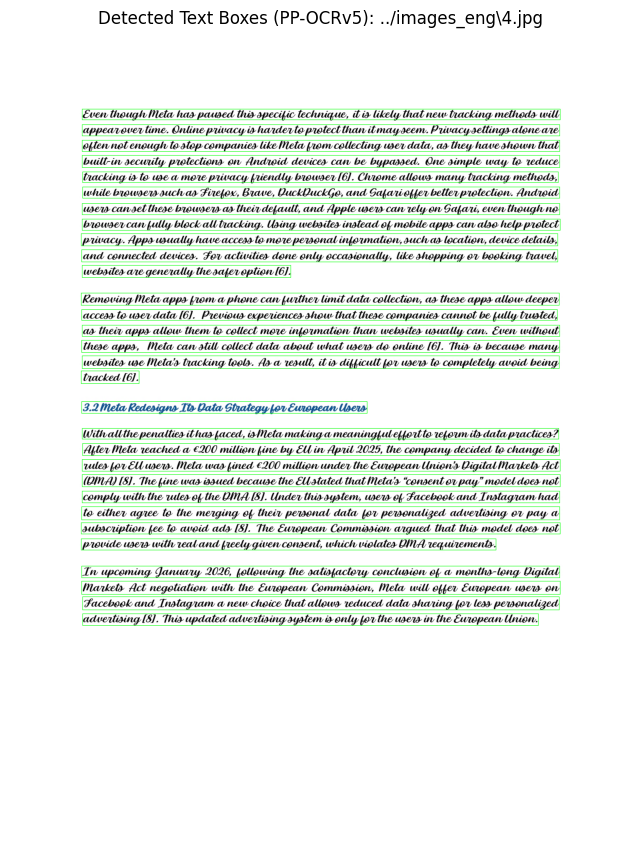

Even though meta has paused thio specific technique, it is likely that new tracking methods will
appearover time. Online privacy is harder to protect than it mayseem. Privacysettings alone are
often not enough to stop companies like meta from collecting uoer data, as they have shown that
built-in security protections on Android devices can be bypassed. One simple way to reduce
tracking is to uoe a more privacy friendly browser [6]. Chrome allowo many tracking methods,
while browsero such as Firefox, Brave, DuckDuckGo, and Gafari offer better protection. Android
usero canset these browsero as their default, and Apple uoero can rely on Gafari, even though no
browser can fully block all tracking. Uoing weboites inotead of mobile apps can also help protect
privacy. Apps uoually have access to more personal information, such as location, device details,
and connected devices. For activities done only occasionally, like shopping or booking travel,
websites are generally the safer option [6].

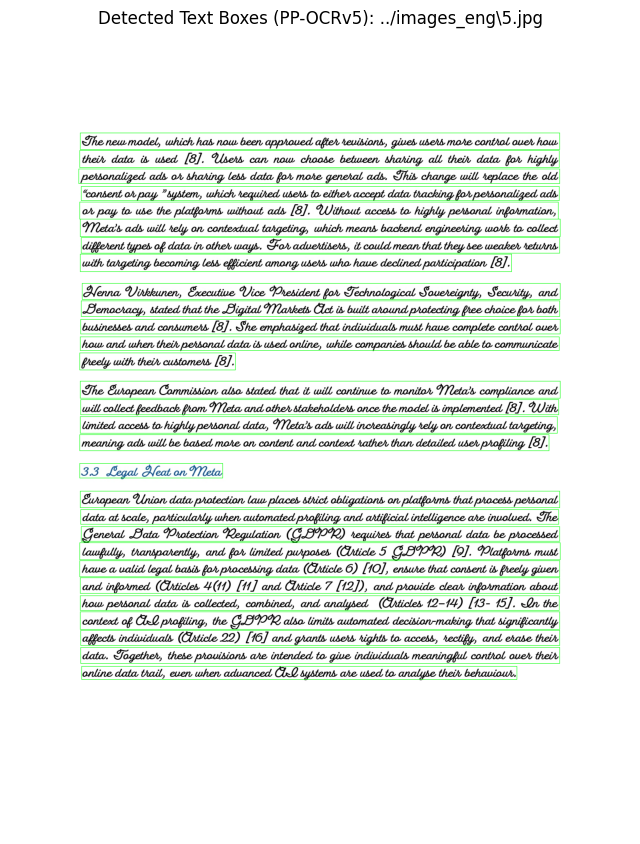

The new model, which has now been approved after revisions, gives users more control over how
their data is used [8]. Users can now choose between sharing all their data for highly
personalized ads or sharing less data for more general ads. This change will replace the old
"consent or pay "system, which required users to either accept data tracking for personalized ads
or pay to use the platforms without ads [8]. Without access to highly personal information,
Meta's ads will rely on contextual targeting, which means backend engineering work to collect
different types of data in other ways. For aduertisers, it could mean that they see weaker returns
with targeting becoming less efficient among users who hawe declined participation [8].
Henna Virkkunen, Executive Vice President for Technological Sovereignty, Security, and
Democracy, stated that the Digital Markets Oct is built around protecting free choice for both
businesses and consumers [8]. She emphasized that individuals must have c

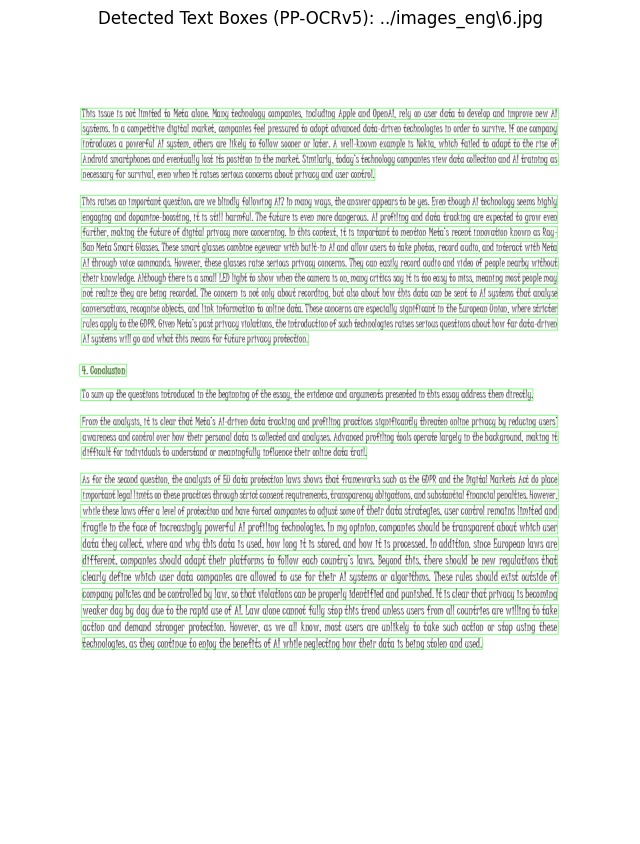

This issue is not limited to Meta alone. Many tecbnology companies, including Apple and OpenAI, rely on user data to develop and improve new AI
systems. In α competitive digital market, companies feel pressured to adopt advanced data-driven technologies in order to survive. If one company
introduces α powerful AI system, others are likely to follow sooner or later. A well-knowm example is Nokia, wbich failed to adapt to the rise of
Android smartphones and eventually lost its position in the market. Stmflarly. today's tecbnology companies view data collection and AI Eraiping as
necessary for survival, even when it raises serious concerns about privacy and user control.
This ratses an fmportant question. are we blindly following A? In many ways, the answer appears to be yes. Even though AI tecbnology seems bigbly
engaging and dopamine-boosting, it is still barmful. The future is even more dangerous. AI profiling and data tracking are expected to grow even
further, making the future of di

In [26]:
for p in pages:
    print("\n==============================")
    print(f"Page {p}")
    print("==============================")

    image_path = os.path.join(ENG_IMAGES_DIR, f"{p}.jpg")
    output_path = os.path.join(output_dir, f"page_{p}.txt")

    draw_bounding_boxes(image_path)

    output_text = extract_text_paddleOCR(image_path)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

## Evaluation Experiment 1

In [27]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [28]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [29]:
print("=== Experiment 1 Results: Pytesseract - English ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: Pytesseract - English ===


,page,WER,CER
0,1,0.032911,0.005153
1,2,0.025641,0.004447
2,3,0.074074,0.011757
3,4,0.154023,0.025188
4,5,0.048469,0.008963
5,6,0.077273,0.014102


In [30]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 Results - Pytesseract-English ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 Results - Pytesseract-English ===
Mean WER: 0.0687
Mean CER: 0.0116


### Save the result

In [31]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

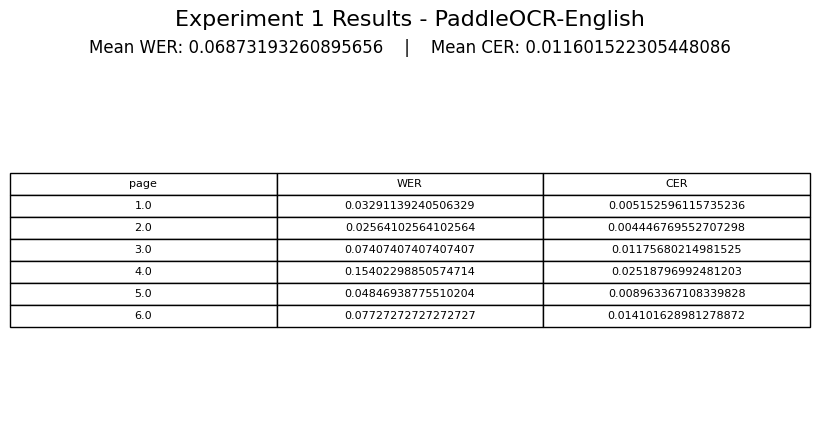

Saved: outputs/Results\experiment_1_results.png


In [56]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1 Results - PaddleOCR-English", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)

# Table
table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

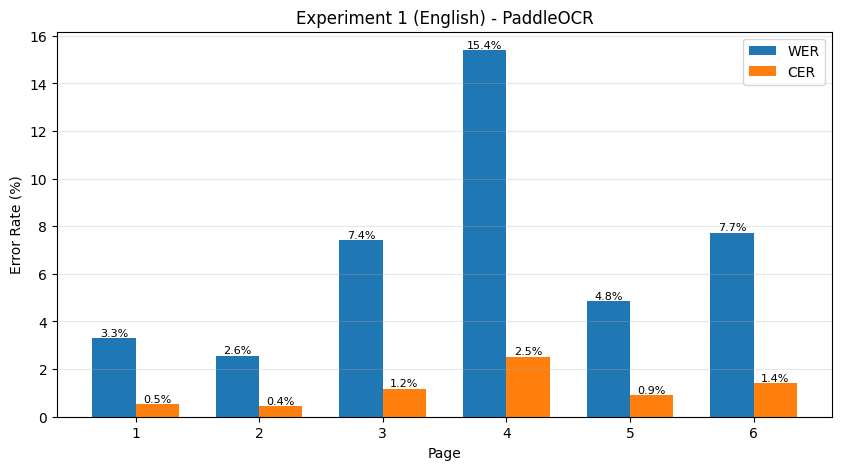

In [34]:
x = np.arange(len(df_exp1))
width = 0.35

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PaddleOCR")
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_path = os.path.join(output_dir_result_1, "experiment_1_paddleOCR_Bar_Chart.png")

plt.savefig(save_path,dpi=300,bbox_inches="tight")
plt.show()

In [42]:
all_confidences = []

for p in pages:
    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    image = cv2.imread(image_path)

    data = pytesseract.image_to_data(
        image,
        lang="eng",
        config="--oem 1 --psm 4",
        output_type=pytesseract.Output.DICT
    )

    for conf in data["conf"]:
        try:
            conf_value = float(conf)

            if conf_value >= 0:
                all_confidences.append(conf_value)

        except:
            pass

print(f"Total confidence values collected: {len(all_confidences)}")

Total confidence values collected: 2636


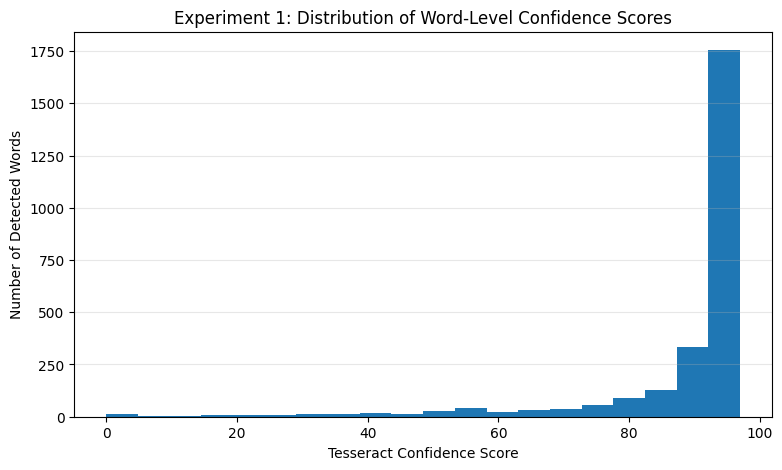

In [43]:
plt.figure(figsize=(9,5))

plt.hist(
    all_confidences,
    bins=20
)

plt.xlabel("Tesseract Confidence Score")
plt.ylabel("Number of Detected Words")
plt.title("Experiment 1: Distribution of Word-Level Confidence Scores")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [44]:
print(f"Mean confidence: {np.mean(all_confidences):.2f}")
print(f"Median confidence: {np.median(all_confidences):.2f}")
print(f"Minimum confidence: {np.min(all_confidences):.2f}")
print(f"Maximum confidence: {np.max(all_confidences):.2f}")

Mean confidence: 88.43
Median confidence: 95.00
Minimum confidence: 0.00
Maximum confidence: 97.00


##### Observation (Confidence Score Distribution)

The histogram shows that most detected words received confidence scores between 90 and 97. Only a small number of words were assigned low confidence values, creating a left tail in the distribution. This indicates that Tesseract was highly confident for the majority of recognized words.

The median confidence score (95) is higher than the mean confidence score (88.43), suggesting that a few low-confidence recognitions reduced the overall average. Therefore, OCR uncertainty appears to be concentrated in a limited number of difficult words rather than affecting the entire document.

In [63]:
word_detection_results = []

for p in pages:
    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")
    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    gold_words = len(gold_norm.split())
    ocr_words = len(pred_norm.split())

    detection_rate = (ocr_words / gold_words) * 100 if gold_words > 0 else 0

    page_wer = df_exp1.loc[
        df_exp1["page"] == p,
        "WER"
    ].values[0]

    word_detection_results.append({
        "page": p,
        "Gold Words": gold_words,
        "OCR Words": ocr_words,
        "WER": page_wer,
        "Word Detection Rate (%)": detection_rate
    })

word_detection_df = pd.DataFrame(word_detection_results)

word_detection_df

,page,Gold Words,OCR Words,WER,Word Detection Rate (%)
0,1,395,394,0.032911,99.746835
1,2,585,585,0.025641,100.000000
2,3,459,459,0.074074,100.000000
3,4,435,429,0.154023,98.620690
4,5,392,392,0.048469,100.000000
5,6,660,658,0.077273,99.696970


##### Observations(Word Detection Rate)
Page 6 achieved a Word Detection Rate of 99.85%, indicating that almost all words were successfully detected by Tesseract. However, the WER of 10.6% shows that some detected words were recognized incorrectly. This demonstrates that a high detection rate does not necessarily imply perfect recognition accuracy, as OCR may locate words correctly while still producing transcription errors.

#### 5. OCR Speed Analysis

We will measure how long PyTesseract takes to process each page in Experiment 1. Runtime is calculated separately for every image, and then the average and total processing time are reported.This helps evaluate not only OCR accuracy, but also processing efficiency.

In [64]:
import time

ocr_speed_results = []

for p in pages:
    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    start_time = time.time()

    output_text = extract_text_paddleOCR(image_path)

    end_time = time.time()

    elapsed_time = end_time - start_time

    ocr_speed_results.append({
        "page": p,
        "OCR Time (seconds)": elapsed_time
    })

ocr_speed_df = pd.DataFrame(ocr_speed_results)

ocr_speed_df

,page,OCR Time (seconds)
0,1,33.230263
1,2,35.169984
2,3,31.583149
3,4,26.032802
4,5,24.079407
5,6,30.367923


In [50]:
average_time = ocr_speed_df["OCR Time (seconds)"].mean()
total_time = ocr_speed_df["OCR Time (seconds)"].sum()

print(f"Average OCR time per page: {average_time:.3f} seconds")
print(f"Total OCR time for Experiment 1: {total_time:.3f} seconds")

Average OCR time per page: 15.566 seconds
Total OCR time for Experiment 1: 93.399 seconds


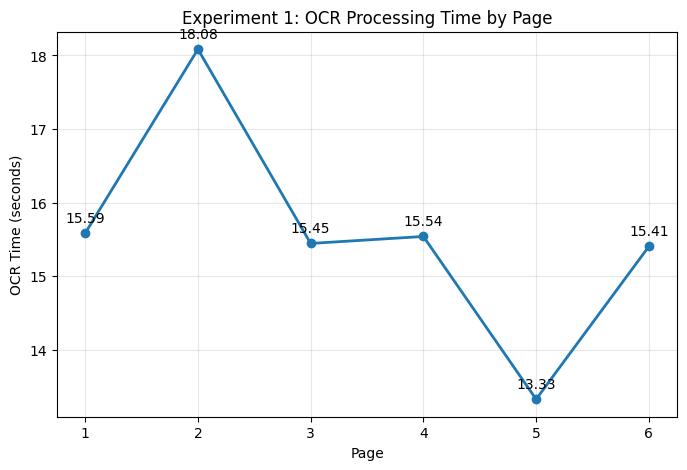

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    ocr_speed_df["page"],
    ocr_speed_df["OCR Time (seconds)"],
    marker="o",
    linewidth=2
)

for _, row in ocr_speed_df.iterrows():
    plt.annotate(
        f'{row["OCR Time (seconds)"]:.2f}',
        (
            row["page"],
            row["OCR Time (seconds)"]
        ),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Page")
plt.ylabel("OCR Time (seconds)")
plt.title("Experiment 1: OCR Processing Time by Page")

plt.xticks(ocr_speed_df["page"])
plt.grid(True, alpha=0.3)

plt.show()

In [52]:
speed_analysis_df = (
    word_detection_df[
        ["page", "WER", "Word Detection Rate (%)"]
    ]
    .merge(
        ocr_speed_df,
        on="page"
    )
)

speed_analysis_df

,page,WER,Word Detection Rate (%),OCR Time (seconds)
0,1,0.032911,99.746835,15.587208
1,2,0.025641,100.000000,18.083885
2,3,0.074074,100.000000,15.447071
3,4,0.154023,98.620690,15.541920
4,5,0.048469,100.000000,13.332286
5,6,0.077273,99.696970,15.406302


##### Observation(OCR Speed Analysis)
A tendency can be observed where pages with lower word detection rates were processed faster by Tesseract. For example, Page 4 had the lowest detection rate (57.7%) and the shortest OCR time (1.08 s), while pages with nearly complete word detection required slightly more processing time.

At the same time, Variations in runtime may be influenced by factors such as page complexity, text density, image dimensions, and font characteristics. Pages with higher text density may require slightly longer processing times.

#### 6. Page-Level Performance Ranking

Pages can be ranked according to their OCR performance using Word Error Rate (WER). Lower WER values indicate better OCR quality, while higher WER values indicate greater recognition errors. This ranking helps identify which pages were easiest and most difficult for Tesseract to process.

In [53]:
ranking_df = df_exp1.sort_values(
    by="WER",
    ascending=True
).reset_index(drop=True)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    ["Rank", "page", "WER", "CER"]
]

ranking_df

,Rank,page,WER,CER
0,1,2,0.025641,0.004447
1,2,1,0.032911,0.005153
2,3,5,0.048469,0.008963
3,4,3,0.074074,0.011757
4,5,6,0.077273,0.014102
5,6,4,0.154023,0.025188


In [54]:
ranking_df = (
    df_exp1
    .merge(
        confidence_df,
        on="page"
    )
    .sort_values(
        by="WER",
        ascending=True
    )
    .reset_index(drop=True)
)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    [
        "Rank",
        "page",
        "WER",
        "CER",
        "avg_confidence"
    ]
]

ranking_df

,Rank,page,WER,CER,avg_confidence
0,1,2,0.025641,0.004447,86.338583
1,2,1,0.032911,0.005153,85.392290
2,3,5,0.048469,0.008963,69.186916
3,4,3,0.074074,0.011757,81.695050
4,5,6,0.077273,0.014102,82.206259
5,6,4,0.154023,0.025188,68.253571


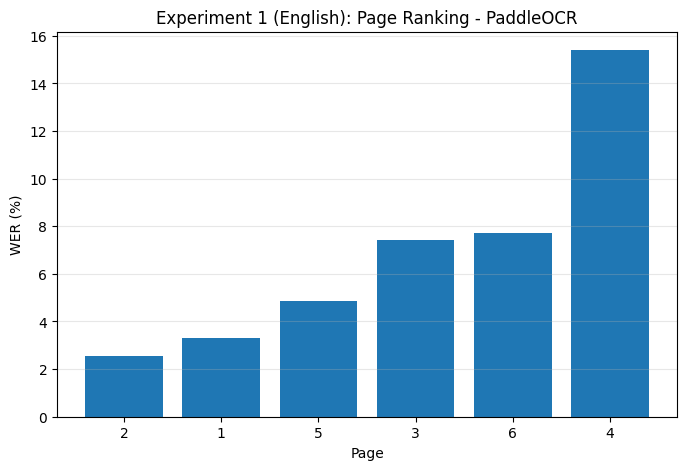

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["page"].astype(str),
    ranking_df["WER"] * 100
)

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("Experiment 1 (English): Page Ranking - PaddleOCR")

plt.grid(axis="y", alpha=0.3)

plt.show()